In [ ]:
!pip install -U sentence-transformers

from sentence_transformers import SentenceTransformer, util

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 171.5/171.5 kB 3.6 MB/s eta 0:00:00
  Using cached nvidia_cuda_nvrtc_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (23.7 MB)
  Using cached nvidia_cuda_runtime_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (823 kB)
  Using cached nvidia_cuda_cupti_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (14.1 MB)
  Using cached nvidia_cudnn_cu12-8.9.2.26-py3-none-manylinux1_x86_64.whl (731.7 MB)
  Using cached nvidia_cublas_cu12-12.1.3.1-py3-none-manylinux1_x86_64.whl (410.6 MB)
  Using cached nvidia_cufft_cu12-11.0.2.54-py3-none-manylinux1_x86_64.whl (121.6 MB)
  Using cached nvidia_curand_cu12-10.3.2.106-py3-none-manylinux1_x86_64.whl (56.5 MB)
  Using cached nvidia_cusolver_cu12-11.4.5.107-py3-none-manylinux1_x86_64.whl (124.2 MB)
  Using cached nvidia_cusparse_cu12-12.1.0.106-py3-none-manylinux1_x86_64.whl (196.0 MB)
  Using cached nvidia_nccl_cu12-2.19.3-py3-none-manylinux1_x86_64.whl (166.0 MB)
  Using cached nvidia_nvtx_cu12-12.1.105-py3-none-many

In [ ]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
from sklearn.metrics.pairwise import cosine_similarity

In [ ]:
#from google.colab import drive
#drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Step 1: Load the CSV file into a DataFrame
#df = pd.read_csv('/content/drive/My Drive/overview-of-recordings.csv')

df = pd.read_csv('https://www.dropbox.com/scl/fi/qvzhk2zp8f2wpnz7hrqyd/overview-of-recordings.csv?rlkey=vugax3x2k76botbpberqbqzve&st=9omelcyw&dl=1')

df.head(10)

,audio_clipping,audio_clipping:confidence,background_noise_audible,background_noise_audible:confidence,overall_quality_of_the_audio,quiet_speaker,quiet_speaker:confidence,speaker_id,file_download,file_name,phrase,prompt,writer_id
0,no_clipping,1.0000,light_noise,1.0000,3.33,audible_speaker,1.0,43453425,https://ml.sandbox.cf3.us/cgi-bin/index.cgi?do...,1249120_43453425_58166571.wav,When I remember her I feel down,Emotional pain,21665495
1,light_clipping,0.6803,no_noise,0.6803,3.33,audible_speaker,1.0,43719934,https://ml.sandbox.cf3.us/cgi-bin/index.cgi?do...,1249120_43719934_43347848.wav,When I carry heavy things I feel like breaking...,Hair falling out,44088126
2,no_clipping,1.0000,no_noise,0.6655,3.33,audible_speaker,1.0,43719934,https://ml.sandbox.cf3.us/cgi-bin/index.cgi?do...,1249120_43719934_53187202.wav,there is too much pain when i move my arm,Heart hurts,44292353
3,no_clipping,1.0000,light_noise,1.0000,3.33,audible_speaker,1.0,31349958,https://ml.sandbox.cf3.us/cgi-bin/index.cgi?do...,1249120_31349958_55816195.wav,My son had his lip pierced and it is swollen a...,Infected wound,43755034
4,no_clipping,1.0000,no_noise,1.0000,4.67,audible_speaker,1.0,43719934,https://ml.sandbox.cf3.us/cgi-bin/index.cgi?do...,1249120_43719934_82524191.wav,My muscles in my lower back are aching,Infected wound,21665495
5,no_clipping,1.0000,no_noise,1.0000,3.00,audible_speaker,1.0,40663048,https://ml.sandbox.cf3.us/cgi-bin/index.cgi?do...,1249120_40663048_51348478.wav,i have muscle pain that my back\nI Have Muscle...,Foot ache,44130352
6,no_clipping,1.0000,no_noise,1.0000,3.67,audible_speaker,1.0,40663048,https://ml.sandbox.cf3.us/cgi-bin/index.cgi?do...,1249120_40663048_42741720.wav,I have muscle pain in my left leg,Shoulder pain,43913997
7,no_clipping,1.0000,no_noise,1.0000,4.25,audible_speaker,1.0,15004831,https://ml.sandbox.cf3.us/cgi-bin/index.cgi?do...,1249120_15004831_21919890.wav,I have cut my finger because of playing footba...,Injury from sports,43318517
8,no_clipping,0.6978,no_noise,1.0000,3.67,audible_speaker,1.0,14353703,https://ml.sandbox.cf3.us/cgi-bin/index.cgi?do...,1249120_14353703_93481996.wav,I have acne in my face and other problems in m...,Skin issue,44066678
9,no_clipping,1.0000,no_noise,0.6879,3.33,audible_speaker,1.0,43719934,https://ml.sandbox.cf3.us/cgi-bin/index.cgi?do...,1249120_43719934_85316490.wav,I have a strange rash on my arm,Foot ache,44130352


In [ ]:
# Drop all columns except 'phrase' and 'prompt'
df = df[['phrase', 'prompt']]

# Display the DataFrame
print(df.head(10))

                                              phrase              prompt
0                    When I remember her I feel down      Emotional pain
1  When I carry heavy things I feel like breaking...    Hair falling out
2          there is too much pain when i move my arm         Heart hurts
3  My son had his lip pierced and it is swollen a...      Infected wound
4             My muscles in my lower back are aching      Infected wound
5  i have muscle pain that my back\nI Have Muscle...           Foot ache
6                  I have muscle pain in my left leg       Shoulder pain
7  I have cut my finger because of playing footba...  Injury from sports
8  I have acne in my face and other problems in m...          Skin issue
9                    I have a strange rash on my arm           Foot ache


In [ ]:
# Check if there are any empty values in the 'phrase' column
empty_phrase = df['phrase'].isna().any()

# Check if there are any empty values in the 'prompt' column
empty_prompt = df['prompt'].isna().any()

# Print the results
if empty_phrase:
    print("There are empty values in the 'phrase' column.")
else:
    print("There are no empty values in the 'phrase' column.")

if empty_prompt:
    print("There are empty values in the 'prompt' column.")
else:
    print("There are no empty values in the 'prompt' column.")

There are no empty values in the 'phrase' column.
There are no empty values in the 'prompt' column.


In [ ]:
num_rows = len(df)
print("Number of rows:", num_rows)

Number of rows: 6661


In [ ]:
# Get the number of unique phrases (X)
num_unique_phrases = df['phrase'].nunique()

# Print the number of unique phrases
print("\nNumber of unique phrases (X):", num_unique_phrases)


Number of unique phrases (X): 706


In [ ]:
# Remove rows with duplicate combinations of 'phrase' and 'prompt'
df = df.drop_duplicates(subset=['phrase', 'prompt'])

num_rows = len(df)
print("Number of rows:", num_rows)

Number of rows: 707


In [ ]:
# Group the DataFrame by 'phrase' and count the number of unique prompts in each group
phrase_groups = df.groupby('phrase')['prompt'].nunique()

# Filter the groups where more than one unique prompt exists
duplicate_phrases = phrase_groups[phrase_groups > 1]

# Iterate through the duplicate phrases and print the corresponding rows
for phrase in duplicate_phrases.index:
    print(f"Phrase: {phrase}")
    print(df[df['phrase'] == phrase])
    print()

Phrase: I lose a lot of my hair
                      phrase            prompt
20   I lose a lot of my hair   Body feels weak
280  I lose a lot of my hair  Hair falling out



In [ ]:
# Drop the row at index 20, the prompt does not match the phrase
df = df.drop(20)

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

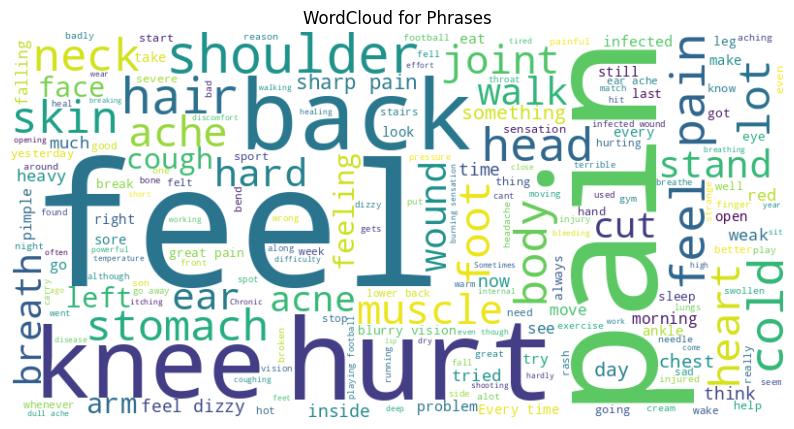

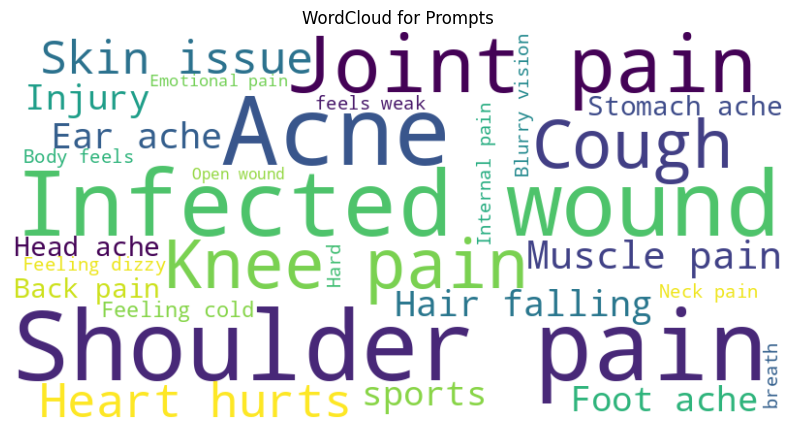

In [ ]:
# Concatenate all text from 'prompts' column into a single string
all_prompts = ' '.join(df['prompt'])

# Concatenate all text from 'phrases' column into a single string
all_phrases = ' '.join(df['phrase'])

# Create a WordCloud object for prompts
wordcloud_prompts = WordCloud(width=800, height=400, background_color='white').generate(all_prompts)

# Create a WordCloud object for phrases
wordcloud_phrases = WordCloud(width=800, height=400, background_color='white').generate(all_phrases)

# Plot WordCloud for phrases
plt.figure(figsize=(10, 6))
plt.imshow(wordcloud_phrases, interpolation='bilinear')
plt.title('WordCloud for Phrases')
plt.axis('off')
plt.show()

# Plot WordCloud for prompts
plt.figure(figsize=(10, 6))
plt.imshow(wordcloud_prompts, interpolation='bilinear')
plt.title('WordCloud for Prompts')
plt.axis('off')
plt.show()

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
import gensim.downloader as api
import pandas as pd

# Download GloVe model
glove_model = api.load("glove-wiki-gigaword-100")

[==================================================] 100.0% 128.1/128.1MB downloaded


In [ ]:
import nltk
nltk.download('stopwords')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

def preprocess_text(text):
    tokens = word_tokenize(text.lower())
    tokens = [token for token in tokens if token.isalpha()]
    embeddings = [glove_model[token] for token in tokens if token in glove_model]
    if embeddings:
        return np.mean(embeddings, axis=0)
    else:
        return np.zeros(glove_model.vector_size)

df['embedding'] = df['phrase'].apply(preprocess_text)
# Prepare the data for training and testing
X = np.vstack(df['embedding'])
y = df['prompt']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a Gradient Boosting Machine classifier
classifier = GradientBoostingClassifier(n_estimators=100, random_state=42)
classifier.fit(X_train, y_train)

# Predict on the test set
y_pred = classifier.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.31690140845070425


In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

def preprocess_text(text):
    tokens = word_tokenize(text.lower())
    tokens = [token for token in tokens if token.isalpha()]
    embeddings = [glove_model[token] for token in tokens if token in glove_model]
    if embeddings:
        return np.mean(embeddings, axis=0)
    else:
        return np.zeros(glove_model.vector_size)
df['embedding'] = df['phrase'].apply(preprocess_text)
# Prepare the data for training and testing
X = np.vstack(df['embedding'])
y = df['prompt']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a Support Vector Machine classifier
classifier = SVC(kernel='linear', random_state=42)
classifier.fit(X_train, y_train)

# Predict on the test set
y_pred = classifier.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)


Accuracy: 0.5915492957746479


In [ ]:
from sklearn.ensemble import RandomForestClassifier
# Preprocess the text data and generate sentence embeddings
def preprocess_text(text):
    tokens = word_tokenize(text.lower())
    tokens = [token for token in tokens if token.isalpha()]
    embeddings = [glove_model[token] for token in tokens if token in glove_model]
    if embeddings:
        return np.mean(embeddings, axis=0)
    else:
        return np.zeros(glove_model.vector_size)

df['embedding'] = df['phrase'].apply(preprocess_text)
# Prepare the data for training and testing
X = np.vstack(df['embedding'])
y = df['prompt']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a Random Forest classifier
classifier = RandomForestClassifier(n_estimators=100, random_state=42)
classifier.fit(X_train, y_train)

# Predict on the test set
y_pred = classifier.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)


Accuracy: 0.3591549295774648


In [ ]:
# Preprocess the text data and generate sentence embeddings
def preprocess_text(text):
    tokens = word_tokenize(text.lower())
    tokens = [token for token in tokens if token.isalpha()]
    embeddings = [glove_model[token] for token in tokens if token in glove_model]
    if embeddings:
        return np.mean(embeddings, axis=0)
    else:
        return np.zeros(glove_model.vector_size)

df['embedding'] = df['phrase'].apply(preprocess_text)

# Prepare the data for training and testing
X = np.vstack(df['embedding'])
y = df['prompt']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a logistic regression classifier
classifier = LogisticRegression(max_iter=1000)
classifier.fit(X_train, y_train)

# Predict on the test set
y_pred = classifier.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)


Accuracy: 0.6197183098591549


In [ ]:
# Example new phrase
new_phrase = "Can't sleep, feeling restless and sore"

# Preprocess the new phrase and generate its sentence embedding
new_embedding = preprocess_text(new_phrase)

# Predict the label for the new phrase using the trained classifier
predicted_label = classifier.predict([new_embedding])[0]

print("Predicted Label for the New Phrase:", predicted_label)

In [ ]:
# Example new phrase
new_phrase = "My knees hurt when I walk"

# Preprocess the new phrase and generate its sentence embedding
new_embedding = preprocess_text(new_phrase)

# Predict the label for the new phrase using the trained classifier
predicted_label = classifier.predict([new_embedding])[0]

print("Predicted Label for the New Phrase:", predicted_label)